In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
cell_gene_fn = r'\\allen\programs\mindscope\workgroups\learning\gene_call\Thyme-736963\cellxgene.csv'
cell_gene = pd.read_csv(cell_gene_fn, index_col=0)

tasic2018_dir = Path(r'\\allen\programs\mindscope\workgroups\learning\jinho\gene_panel_selection\data\mouse_VISp_gene_expression_matrices_2018-06-14')
exon_df = pd.read_feather(tasic2018_dir / 'exon_count.feather')
exon_cpm = pd.read_feather(tasic2018_dir / 'exon_cpm.feather')
exon_tpm = pd.read_feather(tasic2018_dir / 'exon_tpm.feather')
gene_info_fn = tasic2018_dir / 'mouse_VISp_2018-06-14_genes-rows.csv'
sample_info_fn = tasic2018_dir / 'mouse_VISp_2018-06-14_samples-columns.csv'
gene_info_df = pd.read_csv(gene_info_fn, index_col=0)
sample_info_df = pd.read_csv(sample_info_fn, index_col=0)


In [11]:
cell_gene.columns

Index(['cell_id_R1', 'centroids_R1_z', 'centroids_R1_y', 'centroids_R1_x',
       'centroids_R2_z', 'centroids_R2_y', 'centroids_R2_x', 'centroids_R3_z',
       'centroids_R3_y', 'centroids_R3_x', 'fov_id_x', 'cz_stack_id_x',
       'fov_id_y', 'cz_stack_id_y', 'fov_id', 'cz_stack_id', 'users', 'GFP',
       'Slc17a7', 'Gad2', 'Syto59', 'NONE', 'Vip', 'Sst', 'Pvalb', 'Cck',
       'Npy', 'Tac2', 'Calb2', 'Ndnf', 'Tac1', 'AMBIGUOUS-R1', 'AMBIGUOUS-R2',
       'AMBIGUOUS-R3', 'Rn28s-R1', 'Rn28s-R2', 'Rn28s-R3'],
      dtype='object')

In [111]:
gene_list = ['Vip', 'Calb2', 'Cck', 'Tac2', 'Pvalb', 'Sst', 'Npy']
np.all([g in exon_tpm.index for g in gene_list])


True

In [28]:
len(cell_gene)

315

## Filtering
- (ignore) based on GFP call and ambiguity
- Simply follow Marina's filering

In [30]:
cell_gene['AMBIGUOUS-R1'].value_counts()

AMBIGUOUS-R1
0      283
100     26
33       4
50       2
Name: count, dtype: int64

In [31]:
cell_gene['AMBIGUOUS-R2'].value_counts()

AMBIGUOUS-R2
0      268
100     30
50       7
66       6
25       3
33       1
Name: count, dtype: int64

In [32]:
cell_gene['AMBIGUOUS-R3'].value_counts()

AMBIGUOUS-R3
0      221
100     59
50      17
33      11
66       3
25       2
75       1
20       1
Name: count, dtype: int64

In [33]:
cell_gene['GFP'].value_counts()

GFP
100    282
0       25
66       4
50       3
33       1
Name: count, dtype: int64

In [50]:
filtered_cell_gene = cell_gene[(cell_gene['AMBIGUOUS-R1']<50) & (cell_gene['AMBIGUOUS-R2']<50) & (cell_gene['AMBIGUOUS-R3']<50) & (cell_gene['GFP']>0)]
len(filtered_cell_gene)

212

In [207]:
filtered_cell_gene = cell_gene[(cell_gene['AMBIGUOUS-R1']==0) & (cell_gene['AMBIGUOUS-R2']==0) & (cell_gene['GFP']>0)].copy()
len(filtered_cell_gene)

252

## Binarize
- with metadata

In [55]:
filtered_cell_gene.index.values[0]

1

In [208]:
if 'Cell ' in str(filtered_cell_gene.index.values[0]):
    filtered_cell_gene.index = [int(x.split(' ')[1]) for x in filtered_cell_gene.index.values]
metadata_cols = ['fov_id', 'cz_stack_id', 'cell_id_R1', 'centroids_R1_z', 'centroids_R1_x', 'centroids_R1_y']
filtered_binary_call = filtered_cell_gene[gene_list].copy()
# filtered_binary_call = (filtered_binary_call[gene_list] >= 50).astype(int)
filtered_binary_call = (filtered_binary_call[gene_list] > 0).astype(int)
filtered_binary_call = pd.concat([filtered_binary_call, filtered_cell_gene[metadata_cols]], axis=1)
filtered_binary_call

,Vip,Calb2,Cck,Tac2,Pvalb,Sst,Npy,fov_id,cz_stack_id,cell_id_R1,centroids_R1_z,centroids_R1_x,centroids_R1_y
1,1,1,0,1,0,0,0,VISp_0_8,336,45785,642,6668,7084
2,1,1,0,1,0,0,0,VISp_0_3,352,47132,653,6936,6572
5,1,0,0,1,0,0,1,VISp_0_16,378,44599,631,6248,6708
6,0,0,0,0,0,1,1,VISp_0_43,382,40155,592,4680,9244
7,1,0,1,1,0,0,1,VISp_0_50,383,35113,546,4564,8536
...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,1,1,0,0,0,0,0,VISp_7_5,743,109745,1153,6260,8540
304,1,1,0,0,0,0,0,VISp_7_68,746,99102,1036,4052,8828
312,1,1,0,1,0,0,0,VISp_7_52,754,101997,1066,4928,6732
314,1,1,0,0,0,0,0,VISp_7_26,756,110049,1157,5364,8764


In [271]:
filtered_binary_call['fov_ind'] = filtered_binary_call['fov_id'].apply(lambda x: x.split('_')[1])

In [273]:
filtered_binary_call['fov_ind'].values

array(['0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0',
       '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0',
       '0', '0', '0', '0', '1', '1', '1', '1', '1', '1', '1', '1', '1',
       '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1',
       '1', '1', '1', '1', '2', '2', '2', '2', '2', '2', '2', '2', '2',
       '2', '2', '2', '2', '2', '2', '2', '2', '2', '2', '2', '2', '2',
       '2', '2', '2', '2', '2', '2', '2', '2', '2', '2', '2', '2', '2',
       '2', '2', '2', '1', '3', '3', '3', '3', '3', '3', '3', '3', '3',
       '3', '3', '3', '3', '3', '3', '3', '3', '3', '3', '3', '3', '3',
       '3', '3', '3', '3', '3', '3', '3', '3', '4', '4', '4', '4', '4',
       '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4',
       '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4',
       '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4',
       '4', '4', '5', '5', '5', '5', '5', '5', '5', '5', '5', '5

In [272]:
filtered_binary_call.fov_ind.value_counts()

fov_ind
4    46
5    44
2    38
0    30
3    30
6    29
1    27
7     8
Name: count, dtype: int64

In [286]:
242/252*5.27

5.060873015873016

In [275]:
filtered_binary_call.sort_values('centroids_R1_z').fov_ind.values

array(['6', '6', '6', '6', '6', '6', '6', '6', '6', '6', '6', '6', '6',
       '6', '6', '6', '6', '6', '6', '6', '6', '4', '6', '6', '6', '6',
       '4', '6', '4', '6', '4', '4', '6', '4', '4', '4', '4', '4', '4',
       '4', '4', '4', '4', '4', '2', '4', '4', '4', '6', '4', '2', '2',
       '2', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4',
       '2', '4', '4', '2', '4', '2', '4', '4', '4', '4', '2', '4', '2',
       '2', '2', '2', '0', '2', '2', '0', '2', '2', '0', '2', '2', '4',
       '2', '2', '4', '2', '2', '2', '2', '2', '0', '2', '4', '0', '0',
       '0', '4', '2', '2', '2', '2', '2', '2', '4', '2', '0', '4', '2',
       '0', '0', '0', '1', '0', '0', '1', '0', '0', '0', '0', '0', '0',
       '0', '2', '0', '2', '2', '0', '0', '1', '0', '2', '1', '1', '0',
       '0', '1', '1', '1', '1', '0', '0', '1', '1', '1', '1', '1', '1',
       '1', '1', '3', '1', '0', '1', '0', '1', '1', '1', '3', '1', '1',
       '3', '3', '3', '1', '3', '3', '3', '3', '3', '3', '1', '1

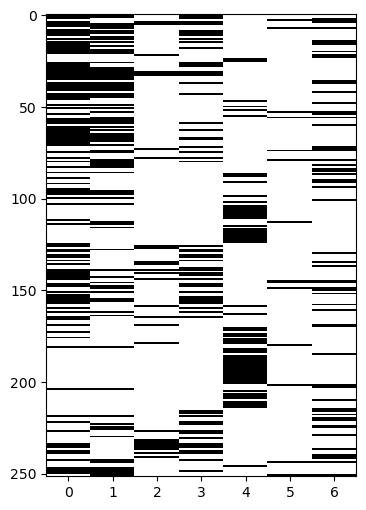

In [289]:
fig, ax = plt.subplots(figsize=(4,6))
ax.imshow(filtered_binary_call[gene_list].values, aspect='auto', cmap='binary', interpolation='none')


[Text(0, 0, '0'), Text(0, 252, '252')]

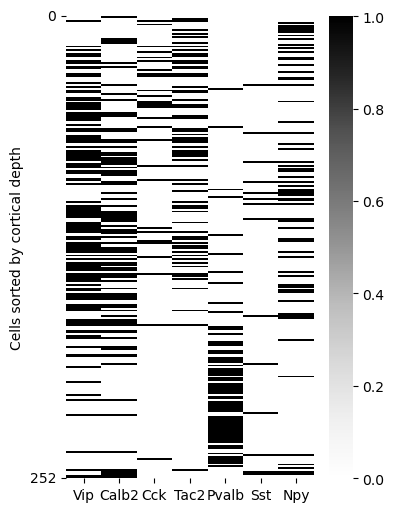

In [209]:
fig, ax = plt.subplots(figsize=(4,6))
ax = sns.heatmap(filtered_binary_call.sort_values('centroids_R1_z')[gene_list], cmap='Grays', ax=ax)
ax.set_ylabel('Cells sorted by cortical depth')
ax.set_yticks((0, filtered_binary_call.shape[0]))
ax.set_yticklabels((0, filtered_binary_call.shape[0]))

## Clustering

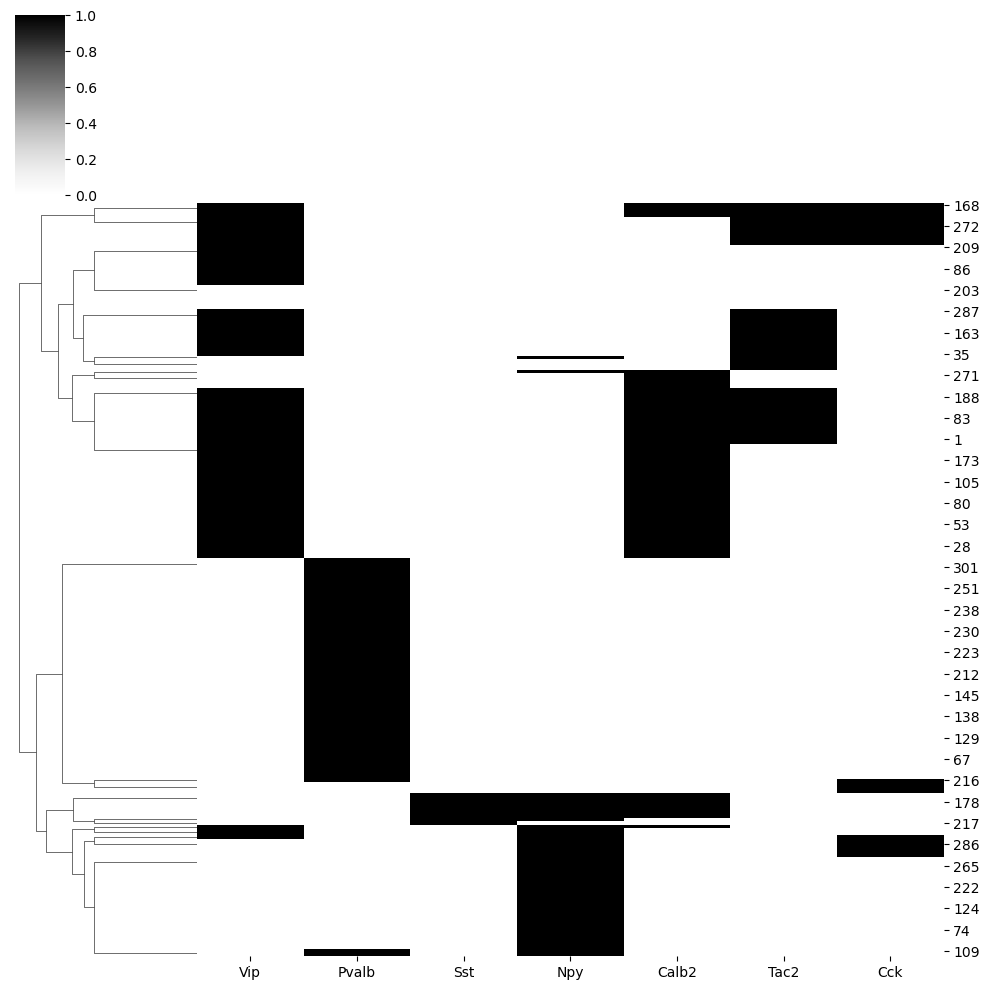

In [114]:
temp_gene_list = ['Vip', 'Pvalb', 'Sst', 'Npy', 'Calb2', 'Tac2', 'Cck']
sns.clustermap(filtered_binary_call[temp_gene_list], cmap='Grays', method='average', row_cluster=True, col_cluster=False)

In [242]:
from sklearn.cluster import KMeans

n_clusters = 11
cells_binary = filtered_binary_call[temp_gene_list].copy()
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto").fit(cells_binary)
cells_binary['cluster_id'] = kmeans.labels_

c:\Users\jinho.kim\Anaconda3\envs\mfish\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [263]:
def plot_clustered_binary_cell_table(cells_binary, n_clusters, gene_order=None, title_base='k ='): 
    '''
    Plot binary heatmap of clustered cell x gene table
    Table must include column for 'cluster_id'
    All other columns should be genes
    n_clusters is the number of clusters (k) used in clustering (typically k-means)
    '''
    if gene_order is None: 
        genes = ['Vip', 'Calb2', 'Cck', 'Tac2', 'Pvalb', 'Sst', 'Npy']
    else:
        genes = gene_order
        
    data = cells_binary.sort_values(by='cluster_id')

    fig, ax = plt.subplots(figsize=(4,6))
    ax = sns.heatmap(data[genes], cmap='Grays', ax=ax, cbar=False)
    ax.set_ylabel('Cells sorted by cluster ID')
    ax.set_yticks((0, cells_binary.shape[0]))
    ax.set_yticklabels((0, cells_binary.shape[0]))
    ax.set_title(title_base+str(n_clusters))

    cluster_boundaries = np.append(np.where(np.diff(data.cluster_id.values)==1)[0], len(data))
    for i, cluster_boundary in enumerate(cluster_boundaries):
        if i != len(cluster_boundaries):
            ax.axhline(y=cluster_boundary+1, xmin=-1, xmax=len(genes), color='g', linestyle='--')
        if i == 0: 
            ax.text(s=str(i+1), x=len(genes)+0.3, y=cluster_boundary/2 - 1, color='g', va='top')
        else: 
            ax.text(s=str(i+1), x=len(genes)+0.3, y=cluster_boundaries[i-1]+((cluster_boundaries[i]-cluster_boundaries[i-1])/2)+1, color='g', va='center')

    ax.spines[['top', 'bottom', 'left', 'right']].set_visible(True)
    return ax


In [254]:
data = cells_binary.sort_values(by='cluster_id')
np.append(np.where(np.diff(data.cluster_id.values)==1)[0], len(data))

array([  6,  50, 115, 119, 148, 185, 201, 212, 230, 242, 252], dtype=int64)

In [246]:
len(data)

252

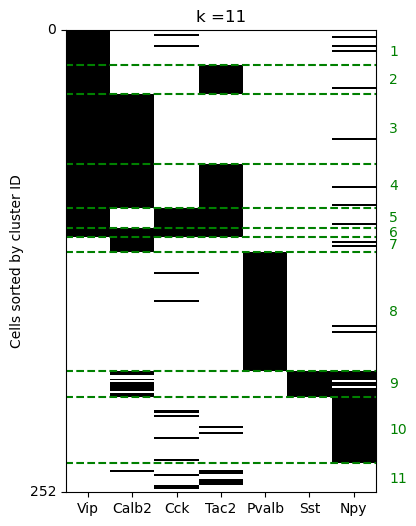

In [313]:
ax = plot_clustered_binary_cell_table(cells_binary, 11)

c:\Users\jinho.kim\Anaconda3\envs\mfish\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jinho.kim\Anaconda3\envs\mfish\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jinho.kim\Anaconda3\envs\mfish\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jinho.kim\Anaconda3\envs\mfish\lib\site-packages\sklearn\cluster\_kmeans.py:1419: 

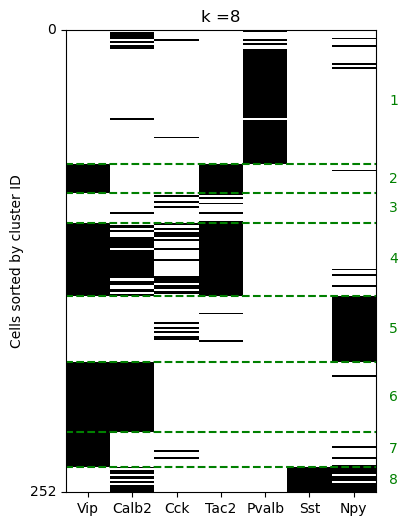

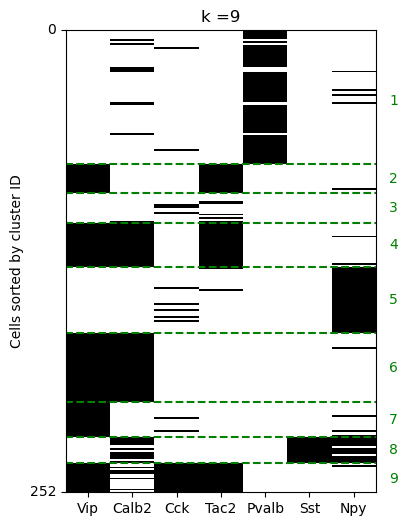

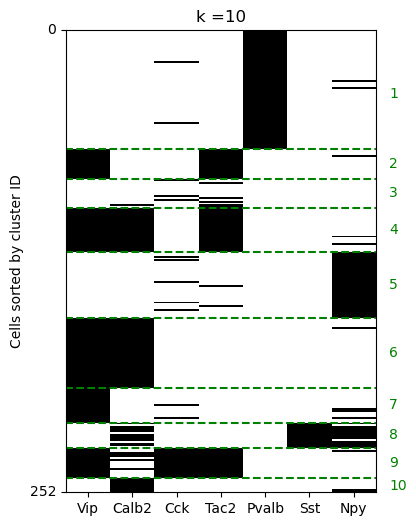

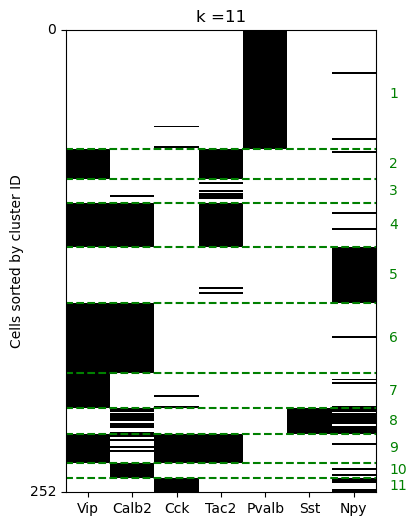

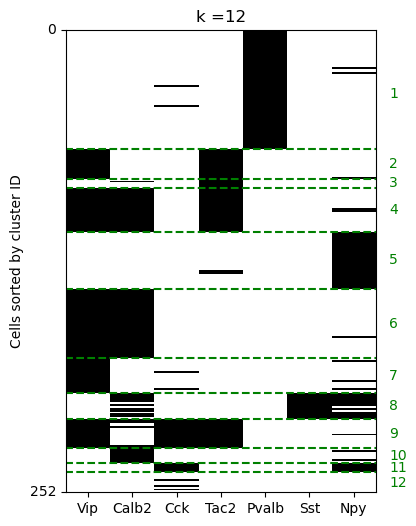

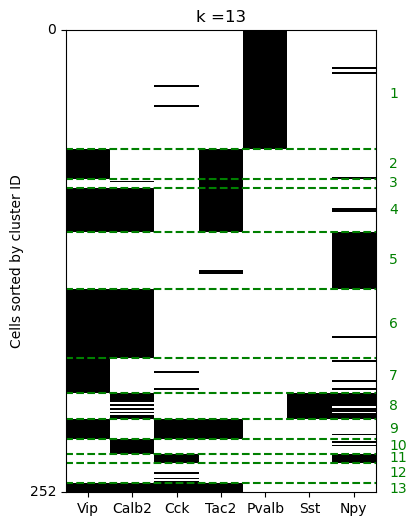

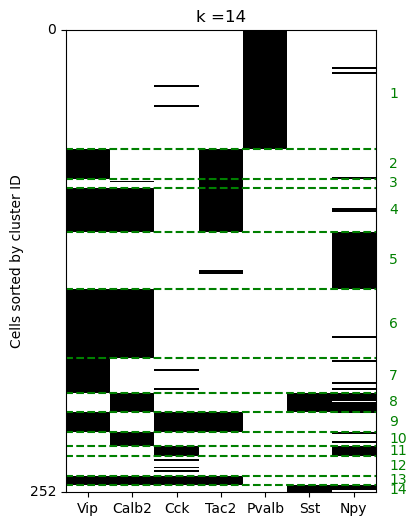

In [290]:
n_clusters_range = np.arange(8, 15)

silhouette_scores = {}
for n_clusters in n_clusters_range:

    X = cells_binary.copy()

    clusterer = KMeans(n_clusters=n_clusters, random_state=10, n_init='auto')
    cluster_labels = clusterer.fit_predict(X)

    X['cluster_id'] = cluster_labels
    plot_clustered_binary_cell_table(X, n_clusters)

## Re-orderging
- k=13

In [291]:
cluster_order = [6, # Vip
                 1, # Vip-Tac2
                 5, # Vip-Calb2
                 3, # Vip-Calb2-Tac2
                #  13, # Vip-Calb2-Tac2-Npy
                #  18, # Vip-Calb2-Cck-Tac2-Npy
                 12, # Vip-Calb2-Cck-Tac2
                 8, # Vip-Cck-Tac2
                #  4, # Vip-Cck-Tac2-Npy
                #  16, # Vip-Cck-Npy
                 10, # Cck-Npy
                 9, # Calb2
                 2, # Tac2
                #  20, # Calb2-Tac2
                #  7, # Pvalb-Cck
                #  2, # Pvalb-Cck-Npy
                 0, # Pvalb
                #  10, # Cck
                #  15, # Pvalb-Sst-Npy
                #  11, # Pvalb-Sst-Npy
                 
                # 14, # Sst-Npy
                #  18, # Sst
                 7, # Sst-Calb2-Npy
                 4, # Npy
                 11, # None
                 ]
# gene_order = ['Vip', 'Calb2', 'Cck', 'Tac2', 'Pvalb', 'Sst', 'Npy', 'Tac1']


c:\Users\jinho.kim\Anaconda3\envs\mfish\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: title={'center': 'k =13'}, ylabel='Cells sorted by cluster ID'>

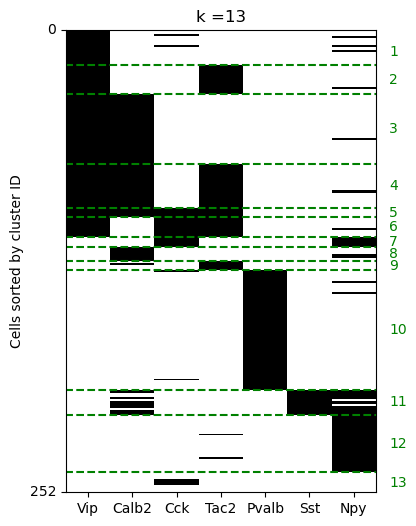

In [293]:
n_clusters = 13
X = cells_binary.copy()

clusterer = KMeans(n_clusters=n_clusters, random_state=10, n_init='auto')
cluster_labels = clusterer.fit_predict(X)

X['cluster_id'] = cluster_labels
if 'kmeans_cluster_id' not in X.columns:
    X['kmeans_cluster_id'] = X['cluster_id'].copy()
    X['sorted_cluster_id'] = [np.where(np.asarray(cluster_order)==cluster_id)[0][0] for cluster_id in X['kmeans_cluster_id'].values]
    X['cluster_id'] = X['sorted_cluster_id']

plot_clustered_binary_cell_table(X, n_clusters)

# Manual clustering
- based on previous k-means clustering results

In [261]:
gene_call_matrix = [[1,0,-1,0,0,0,-1],
                    [1,0,0,1,0,0,-1],

                    [1,1,0,0,0,0,-1],
                    [1,1,0,1,0,0,-1],
                    [1,0,1,1,0,0,-1],
                    [1,1,1,1,0,0,0],
                    
                    [0,1,0,0,0,0,-1],
                    [0,0,-1,0,1,0,-1],
                    [0,-1,0,0,0,1,-1],
                    [0,0,-1,-1,0,0,1]]

In [177]:
def find_matched(binary, gene_call_matrix):
    if isinstance(binary, list):
        binary = np.array(binary)
    matched_row_ind = len(gene_call_matrix)
    for i, row in enumerate(gene_call_matrix):
        row = np.array(row)
        # find non-ignored index
        ni_inds = np.where(np.array(row) > -1)[0]
        if np.all(binary[ni_inds] == row[ni_inds]):
            matched_row_ind = i
        
    return matched_row_ind

<Axes: title={'center': 'Num cluters = 11'}, ylabel='Cells sorted by cluster ID'>

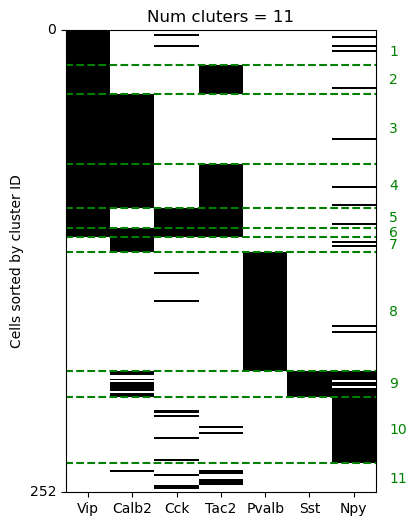

In [265]:
genes = ['Vip', 'Calb2', 'Cck', 'Tac2', 'Pvalb', 'Sst', 'Npy']
cells_binary = filtered_binary_call[genes].copy()
matched_row_ind = []
for i in range(cells_binary.shape[0]):
    matched_row_ind.append(find_matched(cells_binary.iloc[i].values, gene_call_matrix))
cells_binary['cluster_id'] = matched_row_ind
plot_clustered_binary_cell_table(cells_binary, 11, title_base='Num cluters = ')

## Using exon cpm

In [126]:
sample_info_df.columns

Index(['sample_id', 'sample_type', 'organism', 'donor', 'sex', 'age_days',
       'eye_condition', 'genotype', 'driver_lines', 'reporter_lines',
       'brain_hemisphere', 'brain_region', 'brain_subregion',
       'injection_label_direction', 'injection_primary', 'injection_secondary',
       'injection_tract', 'injection_material',
       'injection_exclusion_criterion', 'facs_date', 'facs_container',
       'facs_sort_criteria', 'rna_amplification_set', 'library_prep_set',
       'library_prep_avg_size_bp', 'seq_name', 'seq_tube', 'seq_batch',
       'total_reads', 'percent_exon_reads', 'percent_intron_reads',
       'percent_intergenic_reads', 'percent_rrna_reads',
       'percent_mt_exon_reads', 'percent_reads_unique', 'percent_synth_reads',
       'percent_ecoli_reads', 'percent_aligned_reads_total', 'complexity_cg',
       'genes_detected_cpm_criterion', 'genes_detected_fpkm_criterion',
       'tdt_cpm', 'gfp_cpm', 'class', 'subclass', 'cluster', 'confusion_score',
       'cluste

In [150]:
sample_info_df.set_index('seq_name', inplace=True)
sample_info_df.head()

,sample_id,sample_type,organism,donor,sex,age_days,eye_condition,genotype,driver_lines,reporter_lines,...,genes_detected_cpm_criterion,genes_detected_fpkm_criterion,tdt_cpm,gfp_cpm,class,subclass,cluster,confusion_score,cluster_correlation,core_intermediate_call
seq_name,,,,,,,,,,,,,,,,,,,,,
LS-15006_S09_E1-50,527128530,Cells,Mus musculus,225675,M,53,Normal,Slc32a1-IRES-Cre/wt;Ai14(RCL-tdT)/wt,Slc32a1-IRES-Cre,Ai14(RCL-tdT),...,10445,9222,248.86,248.86,GABAergic,Vip,Vip Arhgap36 Hmcn1,0.4385,0.837229,Intermediate
LS-15006_S10_E1-50,527128536,Cells,Mus musculus,225675,M,53,Normal,Slc32a1-IRES-Cre/wt;Ai14(RCL-tdT)/wt,Slc32a1-IRES-Cre,Ai14(RCL-tdT),...,11600,10370,289.61,289.61,GABAergic,Lamp5,Lamp5 Lsp1,0.1025,0.878743,Core
LS-15006_S11_E1-50,527128542,Cells,Mus musculus,225675,M,53,Normal,Slc32a1-IRES-Cre/wt;Ai14(RCL-tdT)/wt,Slc32a1-IRES-Cre,Ai14(RCL-tdT),...,11848,10734,281.06,281.06,GABAergic,Lamp5,Lamp5 Lsp1,0.0195,0.887084,Core
LS-15006_S12_E1-50,527128548,Cells,Mus musculus,225675,M,53,Normal,Slc32a1-IRES-Cre/wt;Ai14(RCL-tdT)/wt,Slc32a1-IRES-Cre,Ai14(RCL-tdT),...,9494,8561,390.02,390.02,GABAergic,Vip,Vip Crispld2 Htr2c,0.2734,0.843552,Core
LS-15006_S13_E1-50,527128554,Cells,Mus musculus,225675,M,53,Normal,Slc32a1-IRES-Cre/wt;Ai14(RCL-tdT)/wt,Slc32a1-IRES-Cre,Ai14(RCL-tdT),...,10012,8791,253.92,253.92,GABAergic,Lamp5,Lamp5 Plch2 Dock5,0.7532,0.854994,Core


In [151]:
layers = ['L2/3', 'L1', 'L4', 'L1-L4', 'L1-L2/3']
tasic_cells = sample_info_df[(sample_info_df.brain_subregion.isin(layers)) & (sample_info_df['class'] == 'GABAergic')]

In [152]:
tasic_cells.index.values

array(['LS-15006_S09_E1-50', 'LS-15006_S10_E1-50', 'LS-15006_S11_E1-50',
       ..., 'SM-GE63I_S030_E1-50', 'SM-GE63I_S031_E1-50',
       'SM-GE63I_S032_E1-50'], dtype=object)

In [148]:
cpm_data.index.values

array(['LS-14690_S02_E1-50', 'LS-14690_S03_E1-50', 'LS-14690_S05_E1-50',
       ..., 'SQ-80004_S44_E1-50', 'SQ-80004_S47_E1-50',
       'SQ-80004_S48_E1-50'], dtype=object)

In [158]:
cpm_data.loc[tasic_cells.index.values]

gene,Vip,Calb2,Cck,Tac2,Pvalb,Sst,Npy
LS-15006_S09_E1-50,38385.780707,0.000000,0.000000,0.000000,0.000000,0.000000,1.155589
LS-15006_S10_E1-50,0.523664,0.000000,0.000000,0.000000,0.000000,1.047329,18331.919439
LS-15006_S11_E1-50,0.503789,0.000000,0.000000,0.000000,0.000000,0.000000,19733.424956
LS-15006_S12_E1-50,43295.529276,80.294892,19.637338,3959.760040,16.582641,0.000000,0.000000
LS-15006_S13_E1-50,24.467087,0.000000,111.524396,0.000000,0.000000,0.000000,4274.912189
...,...,...,...,...,...,...,...
SM-GE63I_S028_E1-50,62923.855548,386.468884,1.120200,15558.453139,0.000000,2.240399,49.288785
SM-GE63I_S029_E1-50,38790.611702,58.913126,0.000000,4667.637915,0.000000,1.227357,0.000000
SM-GE63I_S030_E1-50,49365.831216,968.244508,2546.085720,7864.111170,0.000000,0.000000,2.091241
SM-GE63I_S031_E1-50,0.000000,0.000000,0.000000,0.000000,0.000000,1.970940,26648.100408


In [219]:
# Limit to genes we care about
cpm_genes = gene_list
cpm_data = exon_cpm.loc[gene_list].T
# Limit to V1 inhibitory cells and transform
cpm_data = cpm_data.loc[tasic_cells.index.values]
print(cpm_data.shape)

(3120, 7)


In [220]:
binary_cpm_data = cpm_data.copy()
threshold = 50 # CPM
binary_cpm_data[binary_cpm_data<threshold] = 0
binary_cpm_data[binary_cpm_data>=threshold] = 1

<Axes: xlabel='gene'>

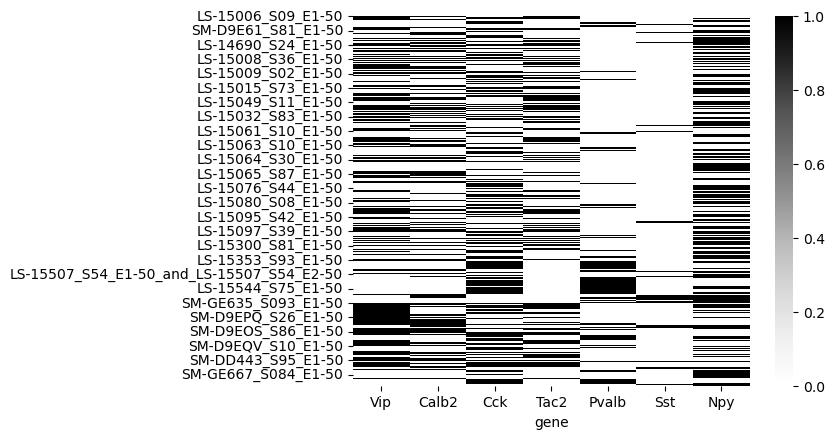

In [163]:
sns.heatmap(binary_cpm_data, cmap='Grays')

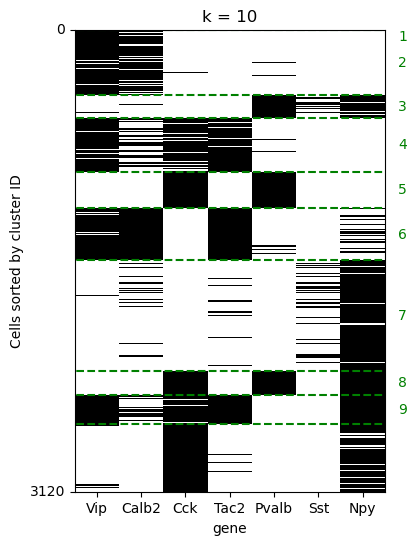

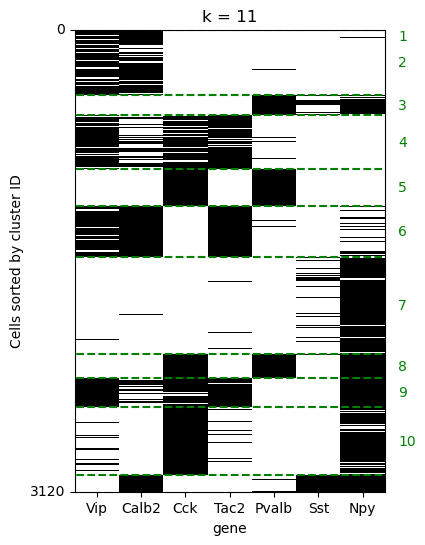

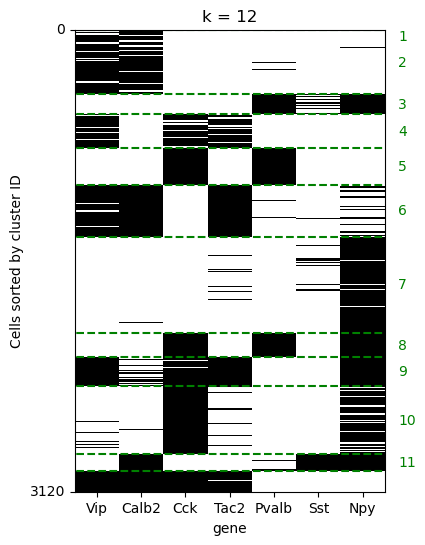

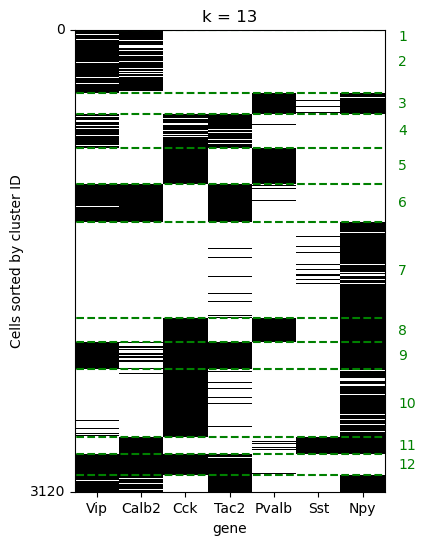

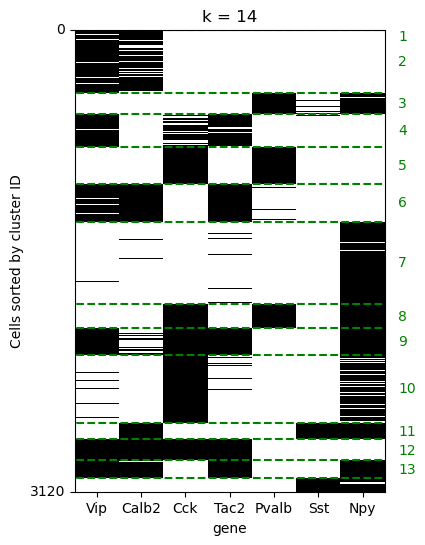

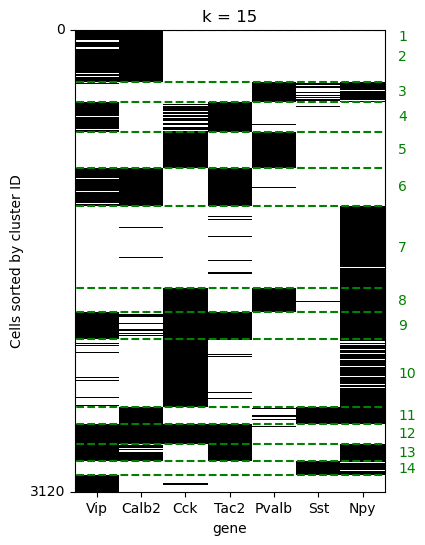

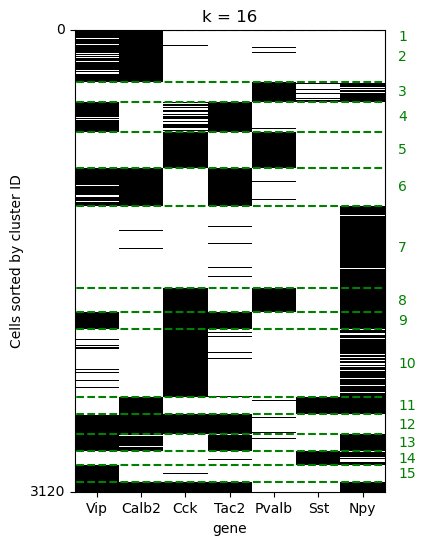

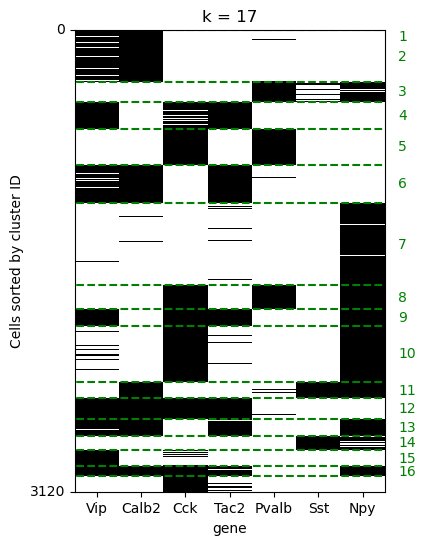

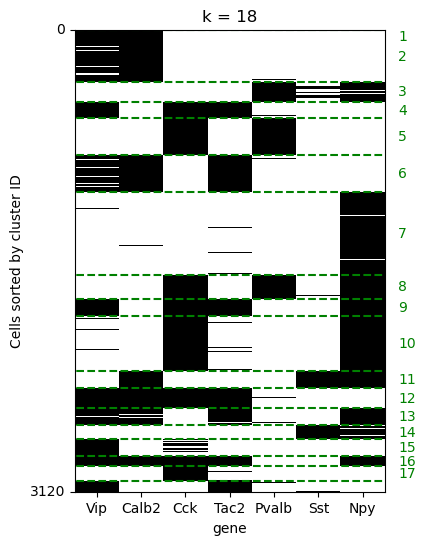

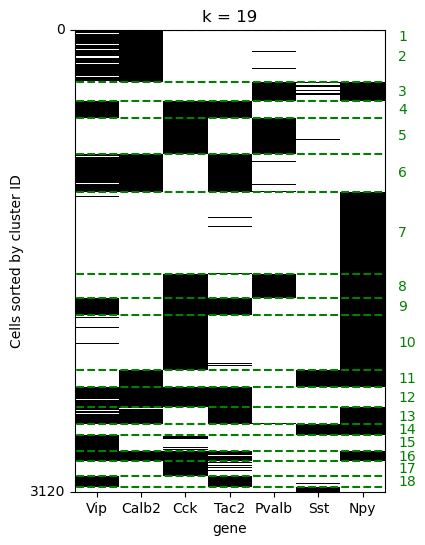

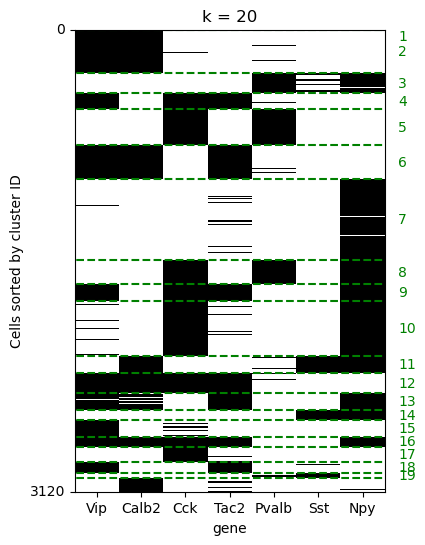

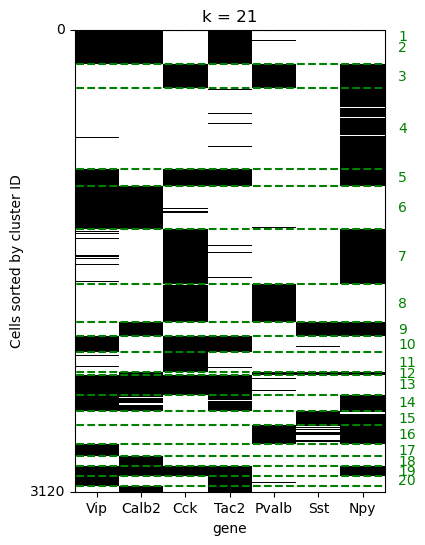

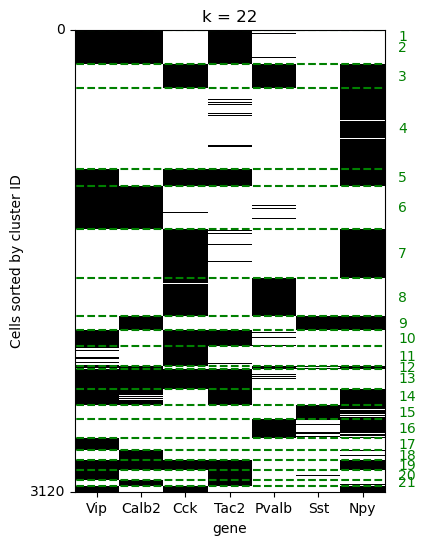

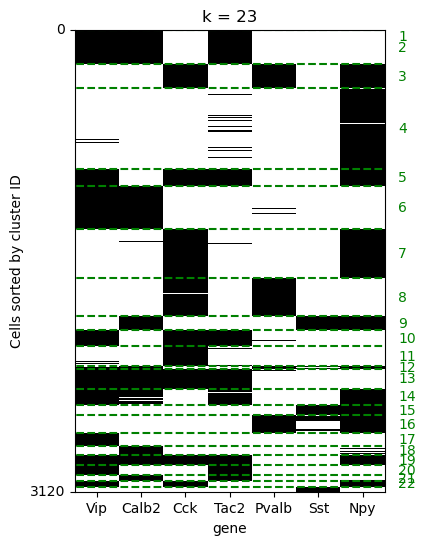

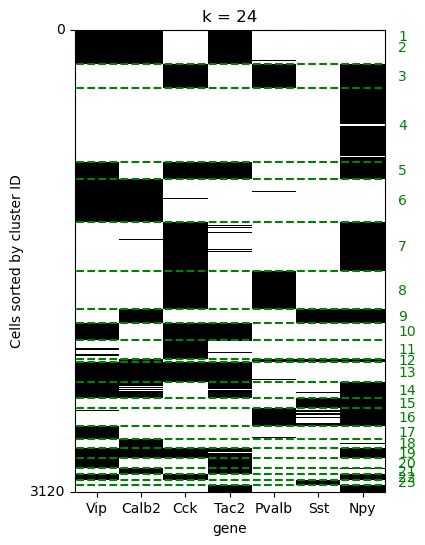

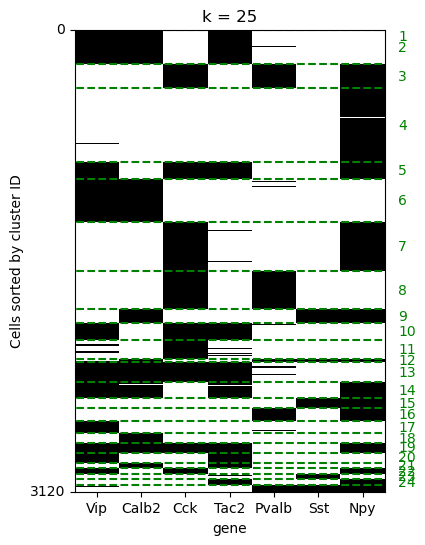

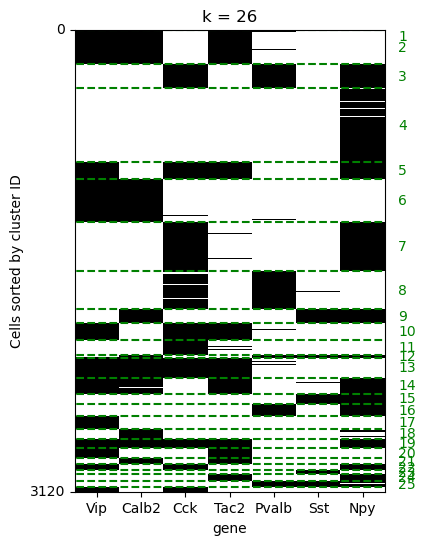

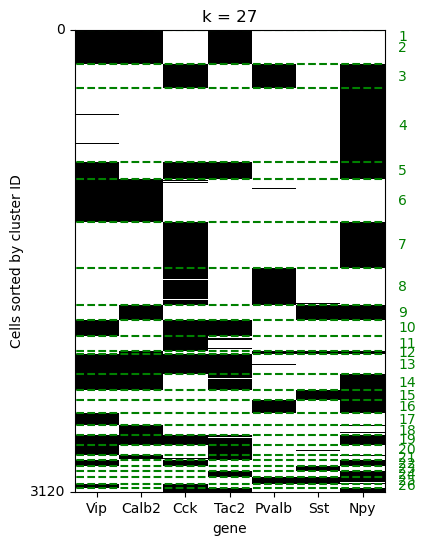

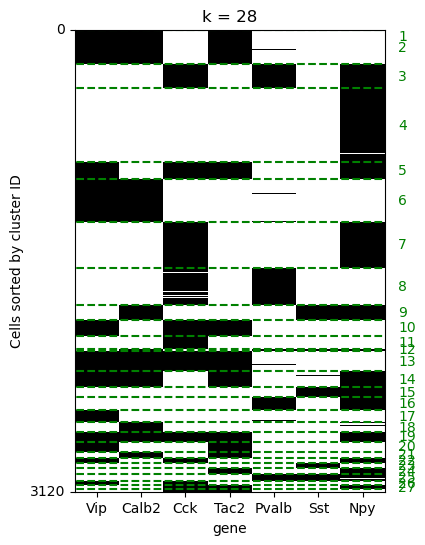

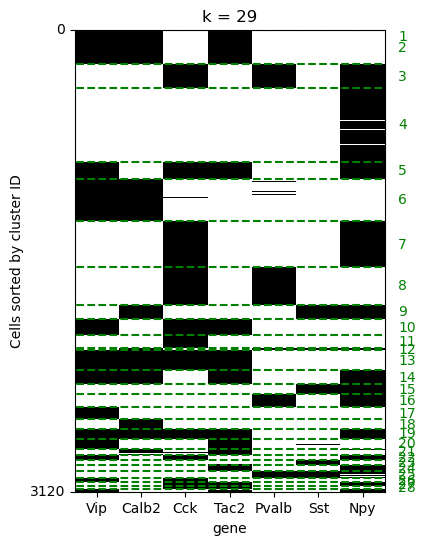

In [165]:
n_clusters_range = np.arange(10, 30)

for n_clusters in n_clusters_range:

    X = binary_cpm_data.copy()

    clusterer = KMeans(n_clusters=n_clusters, random_state=10, n_init='auto')
    cluster_labels = clusterer.fit_predict(X)

    X['cluster_id'] = cluster_labels
    plot_clustered_binary_cell_table(X, n_clusters)

<Axes: title={'center': 'k =21'}, xlabel='gene', ylabel='Cells sorted by cluster ID'>

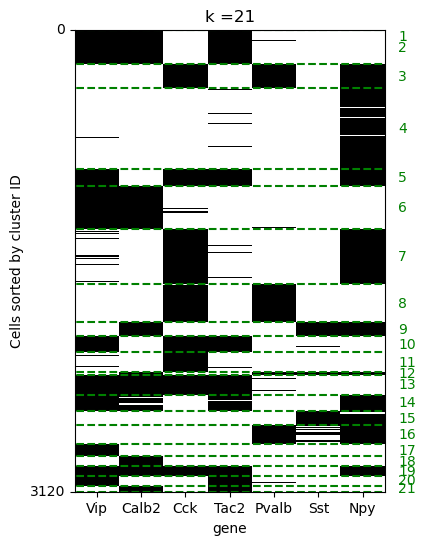

In [295]:
# just choose 21 clusters to match with Marina's results
n_clusters = 21
X = binary_cpm_data.copy()

clusterer = KMeans(n_clusters=n_clusters, random_state=10, n_init='auto')
cluster_labels = clusterer.fit_predict(X)

X['cluster_id'] = cluster_labels
plot_clustered_binary_cell_table(X, n_clusters)

In [228]:
X[X['cluster_id'] == 0]

gene,Vip,Calb2,Cck,Tac2,Pvalb,Sst,Npy,cluster_id
LS-15008_S09_E1-50,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0
LS-15096_S28_E1-50,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0
LS-15579_S58_E1-50,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0
LS-15579_S72_E1-50,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0
SM-GE631_S116_E1-50,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0


In [223]:
np.sum(cluster_labels==0)

5

In [296]:
cluster_order = [16, # Vip
                 19, # Vip-Tac2
                 5, # Vip-Calb2
                 1, # Vip-Calb2-Tac2
                 13, # Vip-Calb2-Tac2-Npy
                 18, # Vip-Calb2-Cck-Tac2-Npy
                 12, # Vip-Calb2-Cck-Tac2
                 9, # Vip-Cck-Tac2
                 4, # Vip-Cck-Tac2-Npy
                #  16, # Vip-Cck-Npy
                 6, # Cck-Npy
                 17, # Calb2
                 20, # Calb2-Tac2
                 7, # Pvalb-Cck
                 2, # Pvalb-Cck-Npy
                 10, # Cck
                #  17, # Pvalb-Cck-Tac1
                #  6, # Pvalb-Cck-Npy-Tac1
                #  19, # Pvalb-Npy-Tac1
                 15, # Pvalb-Sst-Npy
                 11, # Pvalb-Sst-Npy
                0, # Sst-Npy
                14, # Sst-Npy
                #  18, # Sst
                #  1, # Sst-Npy-Tac1
                 8, # Sst-Calb2-Npy
                 3, # Npy
                 ]
# gene_order = ['Vip', 'Calb2', 'Cck', 'Tac2', 'Pvalb', 'Sst', 'Npy', 'Tac1']


<Axes: title={'center': 'k =21'}, xlabel='gene', ylabel='Cells sorted by cluster ID'>

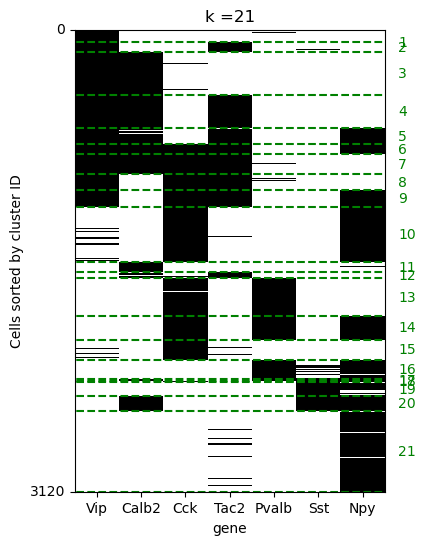

In [297]:
if 'kmeans_cluster_id' not in X.columns:
    X['kmeans_cluster_id'] = X['cluster_id'].copy()
    X['sorted_cluster_id'] = [np.where(np.asarray(cluster_order)==cluster_id)[0][0] for cluster_id in X['kmeans_cluster_id'].values]
    X['cluster_id'] = X['sorted_cluster_id']

plot_clustered_binary_cell_table(X, n_clusters)

In [298]:
X

gene,Vip,Calb2,Cck,Tac2,Pvalb,Sst,Npy,cluster_id,kmeans_cluster_id,sorted_cluster_id
LS-15006_S09_E1-50,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,16,0
LS-15006_S10_E1-50,0.0,0.0,0.0,0.0,0.0,0.0,1.0,20,3,20
LS-15006_S11_E1-50,0.0,0.0,0.0,0.0,0.0,0.0,1.0,20,3,20
LS-15006_S12_E1-50,1.0,1.0,0.0,1.0,0.0,0.0,0.0,3,1,3
LS-15006_S13_E1-50,0.0,0.0,1.0,0.0,0.0,0.0,1.0,9,6,9
...,...,...,...,...,...,...,...,...,...,...
SM-GE63I_S028_E1-50,1.0,1.0,0.0,1.0,0.0,0.0,0.0,3,1,3
SM-GE63I_S029_E1-50,1.0,1.0,0.0,1.0,0.0,0.0,0.0,3,1,3
SM-GE63I_S030_E1-50,1.0,1.0,1.0,1.0,0.0,0.0,0.0,6,12,6
SM-GE63I_S031_E1-50,0.0,0.0,0.0,0.0,0.0,0.0,1.0,20,3,20


In [319]:
cpm_data_norm = cpm_data.copy()
cpm_data_norm = cpm_data_norm.div(cpm_data_norm.max(axis=0), axis=1)


gene,Vip,Calb2,Cck,Tac2,Pvalb,Sst,Npy
LS-15006_S09_E1-50,0.292303,0.000000,0.000000,0.000000,0.000000,0.000000,0.000019
LS-15006_S10_E1-50,0.000004,0.000000,0.000000,0.000000,0.000000,0.000024,0.302340
LS-15006_S11_E1-50,0.000004,0.000000,0.000000,0.000000,0.000000,0.000000,0.325454
LS-15006_S12_E1-50,0.329690,0.007327,0.001137,0.195698,0.003124,0.000000,0.000000
LS-15006_S13_E1-50,0.000186,0.000000,0.006456,0.000000,0.000000,0.000000,0.070504
...,...,...,...,...,...,...,...
SM-GE63I_S028_E1-50,0.479157,0.035268,0.000065,0.768923,0.000000,0.000051,0.000813
SM-GE63I_S029_E1-50,0.295385,0.005376,0.000000,0.230682,0.000000,0.000028,0.000000
SM-GE63I_S030_E1-50,0.375914,0.088359,0.147381,0.388657,0.000000,0.000000,0.000034
SM-GE63I_S031_E1-50,0.000000,0.000000,0.000000,0.000000,0.000000,0.000045,0.439495


In [ ]:
genes = ['Vip', 'Calb2', 'Cck', 'Tac2', 'Pvalb', 'Sst', 'Npy']

[Text(0, 0, '0'), Text(0, 3120, '3120')]

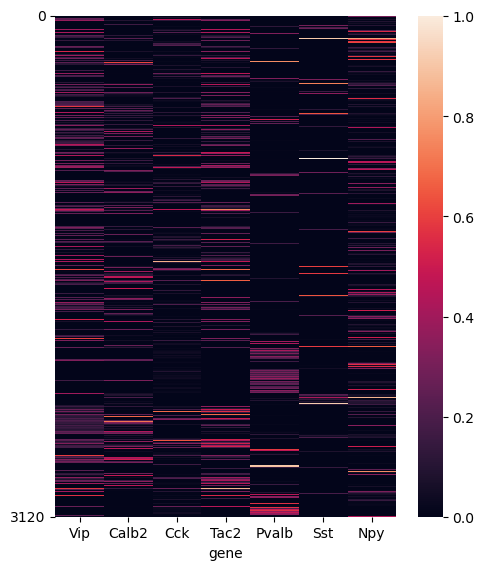

In [335]:
fig, ax = plt.subplots(figsize=(5.5,6.5))
# ax.imshow(cpm_data_norm.values, aspect='auto', cmap='viridis', interpolation='none')
ax = sns.heatmap(cpm_data_norm[genes], ax=ax, )
ax.set_yticks((0, cpm_data_norm.shape[0]))
ax.set_yticklabels((0, cpm_data_norm.shape[0]))


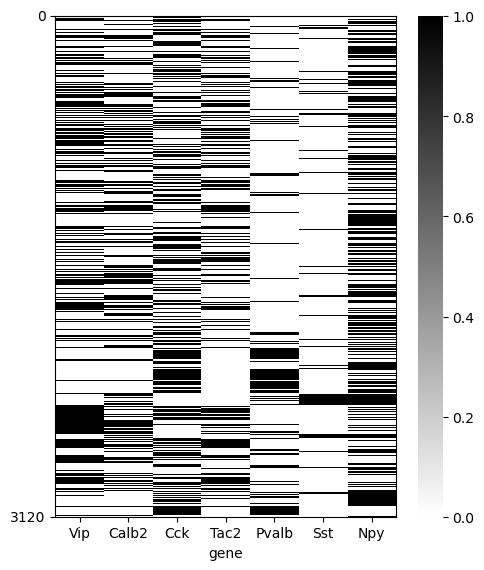

In [338]:
fig, ax = plt.subplots(figsize=(5.5,6.5))
# ax.imshow(cpm_data_norm.values, aspect='auto', cmap='viridis', interpolation='none')
ax = sns.heatmap(binary_cpm_data[genes], ax=ax, cmap='binary')
ax.set_yticks((0, binary_cpm_data.shape[0]))
ax.set_yticklabels((0, binary_cpm_data.shape[0]))
ax.spines[['top', 'bottom', 'left', 'right']].set_visible(True)

In [ ]:
fig, ax = plt.subplots(figsize=(5.5,6.5))
# ax.imshow(cpm_data_norm.values, aspect='auto', cmap='viridis', interpolation='none')
ax = sns.heatmap(cpm_data_norm[genes], ax=ax)
ax.set_yticks((0, cpm_data_norm.shape[0]))
ax.set_yticklabels((0, cpm_data_norm.shape[0]))

In [ ]:
cluster_order = [16, # Vip
                 19, # Vip-Tac2
                 5, # Vip-Calb2
                 1, # Vip-Calb2-Tac2
                 13, # Vip-Calb2-Tac2-Npy
                 18, # Vip-Calb2-Cck-Tac2-Npy
                 12, # Vip-Calb2-Cck-Tac2
                 9, # Vip-Cck-Tac2
                 4, # Vip-Cck-Tac2-Npy
                #  16, # Vip-Cck-Npy
                 6, # Cck-Npy
                 17, # Calb2
                 20, # Calb2-Tac2
                 7, # Pvalb-Cck
                 2, # Pvalb-Cck-Npy
                 10, # Cck
                #  17, # Pvalb-Cck-Tac1
                #  6, # Pvalb-Cck-Npy-Tac1
                #  19, # Pvalb-Npy-Tac1
                 15, # Pvalb-Sst-Npy
                 11, # Pvalb-Sst-Npy
                0, # Sst-Npy
                14, # Sst-Npy
                #  18, # Sst
                #  1, # Sst-Npy-Tac1
                 8, # Sst-Calb2-Npy
                 3, # Npy
                 ]
# gene_order = ['Vip', 'Calb2', 'Cck', 'Tac2', 'Pvalb', 'Sst', 'Npy', 'Tac1']


<Axes: title={'center': 'k =21'}, xlabel='gene', ylabel='Cells sorted by cluster ID'>

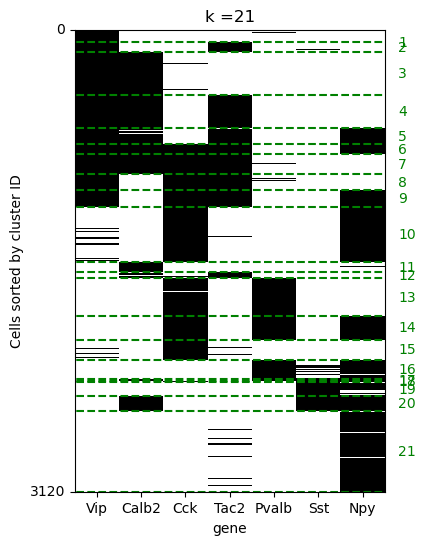

In [ ]:
if 'kmeans_cluster_id' not in X.columns:
    X['kmeans_cluster_id'] = X['cluster_id'].copy()
    X['sorted_cluster_id'] = [np.where(np.asarray(cluster_order)==cluster_id)[0][0] for cluster_id in X['kmeans_cluster_id'].values]
    X['cluster_id'] = X['sorted_cluster_id']

plot_clustered_binary_cell_table(X, n_clusters)

In [311]:
def plot_clustered_scrna(scrna, n_clusters, gene_order=None, title_base='k ='): 
    '''
    Plot binary heatmap of clustered cell x gene table
    Table must include column for 'cluster_id'
    All other columns should be genes
    n_clusters is the number of clusters (k) used in clustering (typically k-means)
    '''
    if gene_order is None: 
        genes = ['Vip', 'Calb2', 'Cck', 'Tac2', 'Pvalb', 'Sst', 'Npy']
    else:
        genes = gene_order
        
    data = scrna.sort_values(by='cluster_id')

    fig, ax = plt.subplots(figsize=(4,6))
    ax = sns.heatmap(data[genes], ax=ax, cbar=True)
    ax.set_ylabel('Cells sorted by cluster ID')
    ax.set_yticks((0, scrna.shape[0]))
    ax.set_yticklabels((0, scrna.shape[0]))
    ax.set_title(title_base+str(n_clusters))

    cluster_boundaries = np.append(np.where(np.diff(data.cluster_id.values)==1)[0], len(data))
    for i, cluster_boundary in enumerate(cluster_boundaries):
        if i != len(cluster_boundaries):
            ax.axhline(y=cluster_boundary+1, xmin=-1, xmax=len(genes), color='g', linestyle='--')
        if i == 0: 
            ax.text(s=str(i+1), x=len(genes)+0.3, y=cluster_boundary/2 - 1, color='g', va='top')
        else: 
            ax.text(s=str(i+1), x=len(genes)+0.3, y=cluster_boundaries[i-1]+((cluster_boundaries[i]-cluster_boundaries[i-1])/2)+1, color='g', va='center')

    ax.spines[['top', 'bottom', 'left', 'right']].set_visible(True)
    return ax


<Axes: title={'center': 'k =21'}, ylabel='Cells sorted by cluster ID'>

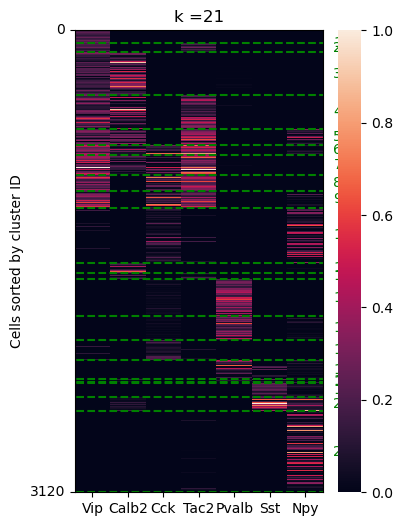

In [312]:
if 'kmeans_cluster_id' not in X.columns:
    X['kmeans_cluster_id'] = X['cluster_id'].copy()
    X['sorted_cluster_id'] = [np.where(np.asarray(cluster_order)==cluster_id)[0][0] for cluster_id in X['kmeans_cluster_id'].values]
    X['cluster_id'] = X['sorted_cluster_id']
Y = cpm_data.copy()
Y = pd.concat([Y, X['cluster_id']], axis=1)
for col in Y.columns:
    if col != 'cluster_id':
        Y[col] = Y[col]/Y[col].max()

plot_clustered_scrna(Y, n_clusters)

# checking cluster level expression pattern

In [341]:
sample_info_df[['cluster']]

,cluster
seq_name,
LS-15006_S09_E1-50,Vip Arhgap36 Hmcn1
LS-15006_S10_E1-50,Lamp5 Lsp1
LS-15006_S11_E1-50,Lamp5 Lsp1
LS-15006_S12_E1-50,Vip Crispld2 Htr2c
LS-15006_S13_E1-50,Lamp5 Plch2 Dock5
...,...
SM-GE63I_S092_E1-50,Sst Hpse Sema3c
SM-GE63I_S093_E1-50,Low Quality
SM-GE63I_S094_E1-50,L5 PT VISp Chrna6


In [346]:
cluster_data_pre = cpm_data.copy()
cluster_data_pre = cluster_data_pre.div(cluster_data_pre.max(axis=0), axis=1)
cluster_data_pre = cluster_data_pre.merge(sample_info_df[['cluster']], left_index=True, right_index=True)
cluster_data_mean = cluster_data_pre.groupby('cluster').mean()
cluster_data_median = cluster_data_pre.groupby('cluster').median()

<Axes: ylabel='cluster'>

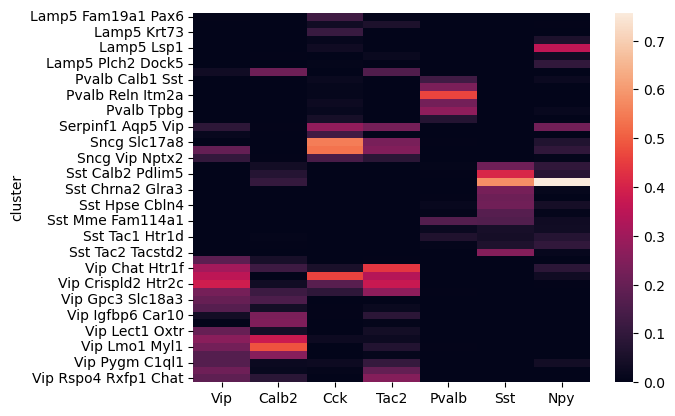

In [348]:
fig, ax = plt.subplots()
sns.heatmap(cluster_data_mean, ax=ax)

<Axes: ylabel='cluster'>

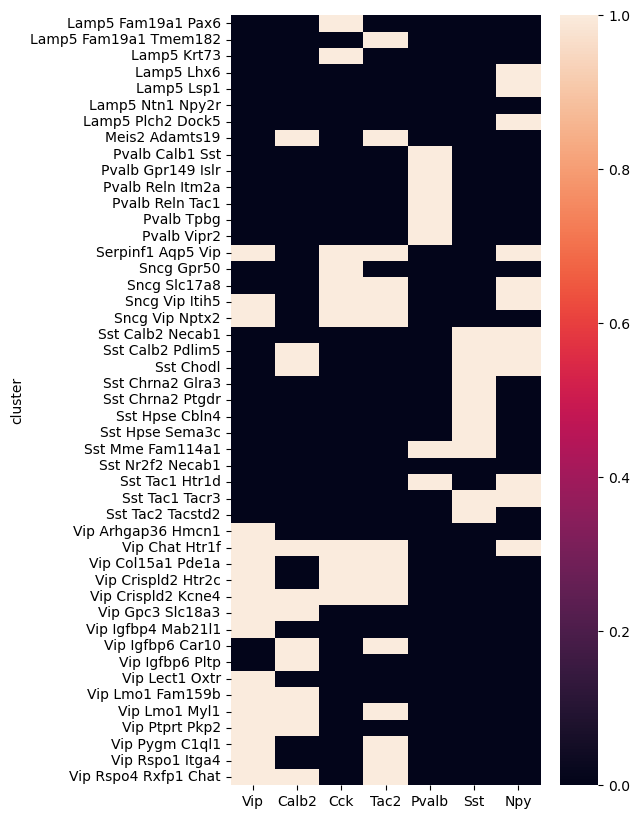

In [354]:
threshold = 0.05
cluster_mean_bin = cluster_data_mean.copy()
cluster_mean_bin[cluster_data_mean>threshold] = 1
cluster_mean_bin[cluster_data_mean<=threshold] = 0
fig, ax = plt.subplots(figsize=(5,10))
sns.heatmap(cluster_mean_bin, ax=ax)

<Axes: ylabel='cluster'>

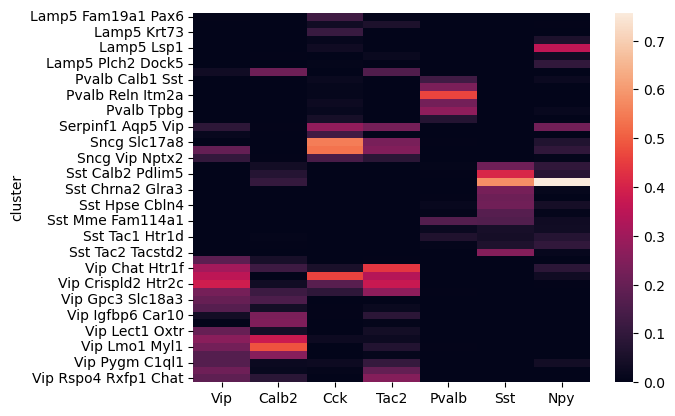

In [349]:
fig, ax = plt.subplots()
sns.heatmap(cluster_data_mean, ax=ax)

# Manual clustering on exon cpm

<Axes: title={'center': 'Num cluters = 11'}, xlabel='gene', ylabel='Cells sorted by cluster ID'>

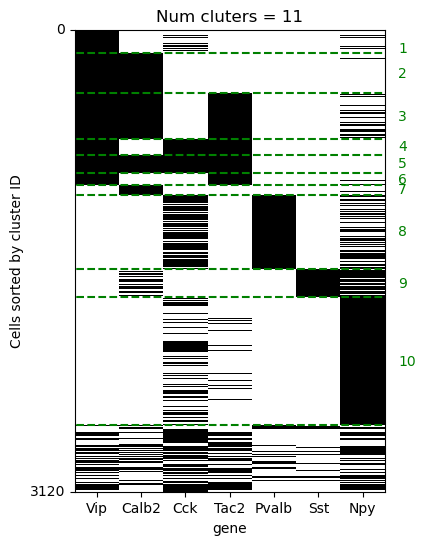

In [201]:
matched_row_ind = []
for i in range(binary_cpm_data.shape[0]):
    matched_row_ind.append(find_matched(binary_cpm_data.iloc[i].values, gene_call_matrix))
binary_cpm_data['cluster_id'] = matched_row_ind
plot_clustered_binary_cell_table(binary_cpm_data, 11, title_base='Num cluters = ')

# What about tpm?

In [202]:
# Limit to genes we care about
tpm_data = exon_tpm.loc[gene_list].T
# Limit to V1 inhibitory cells and transform
tpm_data = tpm_data.loc[tasic_cells.index.values]

<Axes: title={'center': 'Num cluters = 11'}, xlabel='gene', ylabel='Cells sorted by cluster ID'>

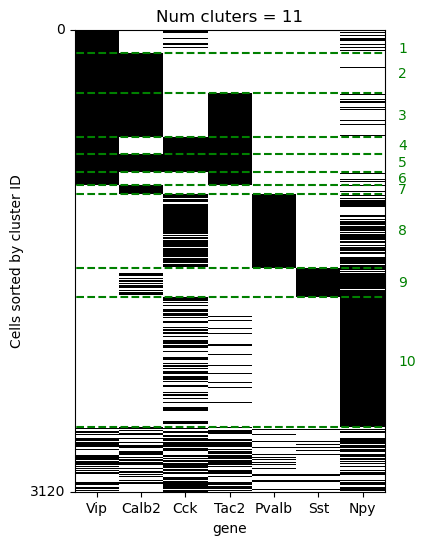

In [206]:
binary_tpm_data = tpm_data.copy()
threshold = 100 # CPM
binary_tpm_data[binary_tpm_data<threshold] = 0
binary_tpm_data[binary_tpm_data>=threshold] = 1

matched_row_ind = []
for i in range(binary_tpm_data.shape[0]):
    matched_row_ind.append(find_matched(binary_tpm_data.iloc[i].values, gene_call_matrix))
binary_tpm_data['cluster_id'] = matched_row_ind
plot_clustered_binary_cell_table(binary_tpm_data, 11, title_base='Num cluters = ')

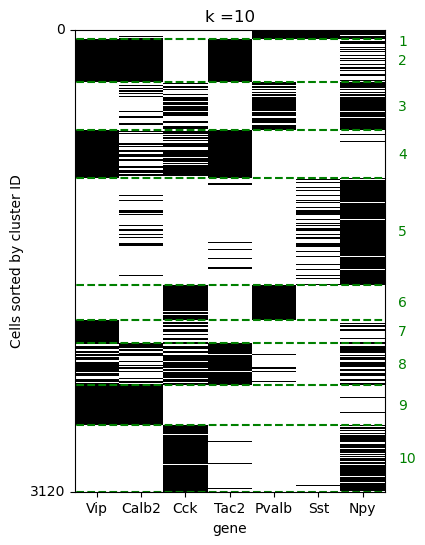

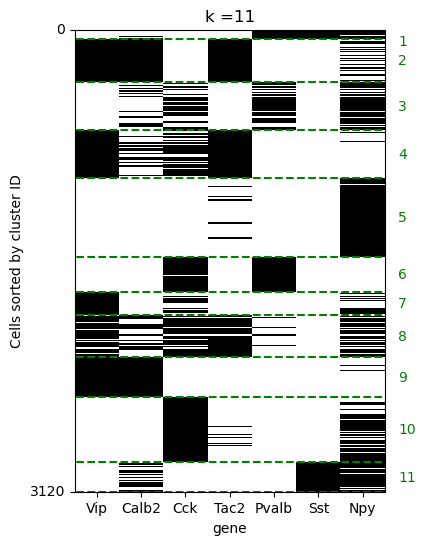

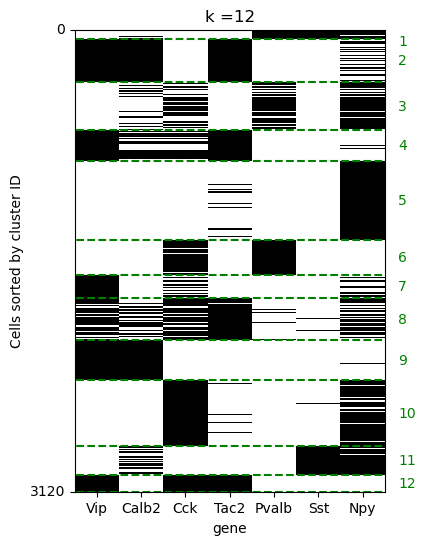

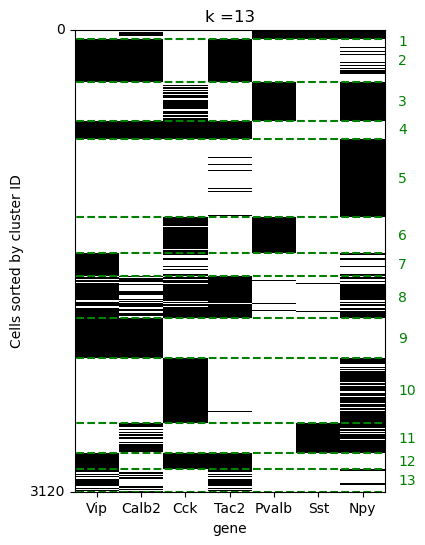

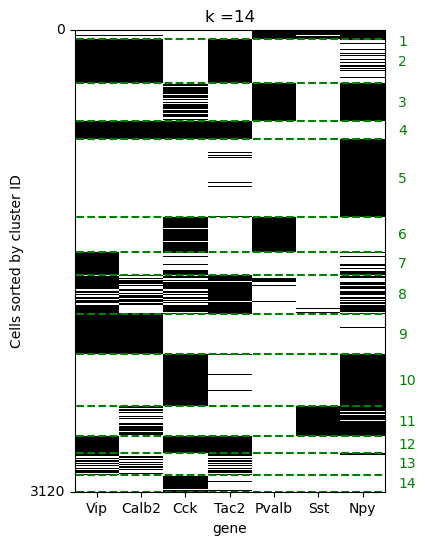

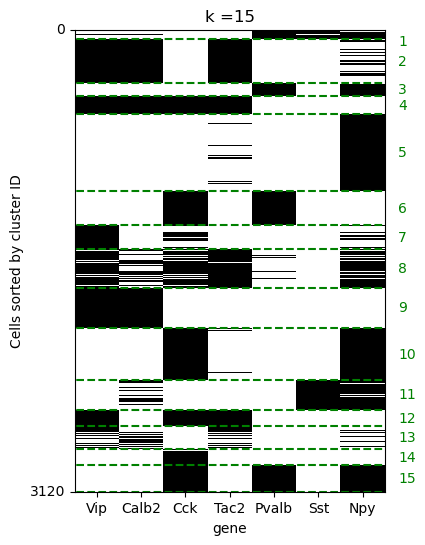

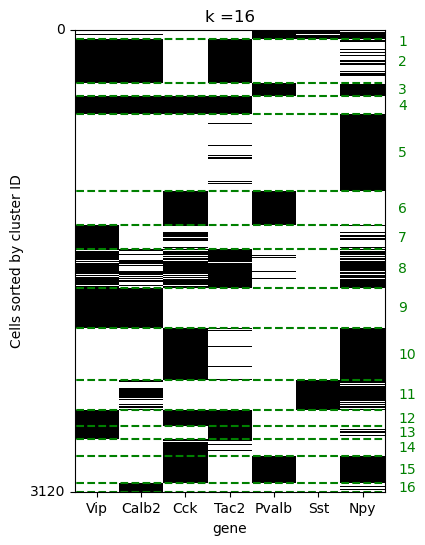

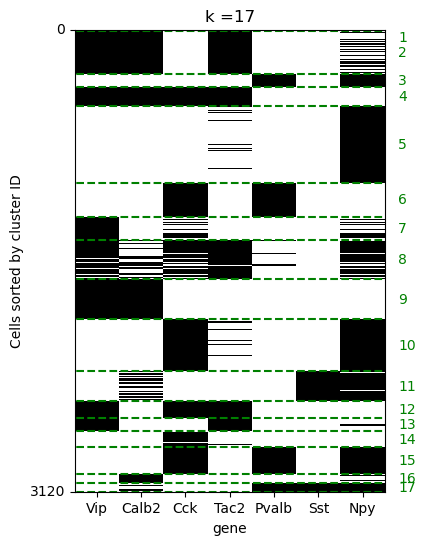

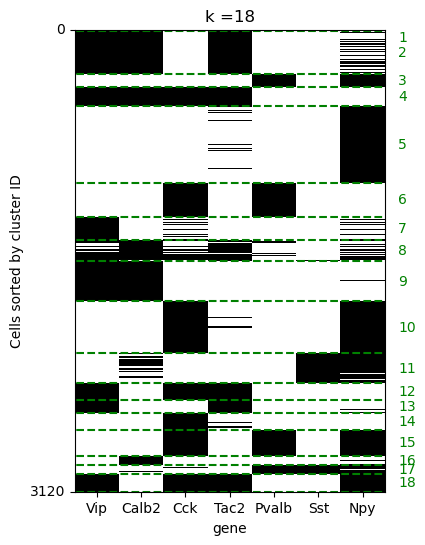

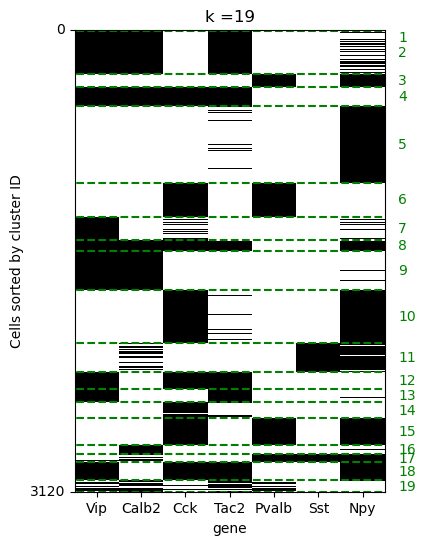

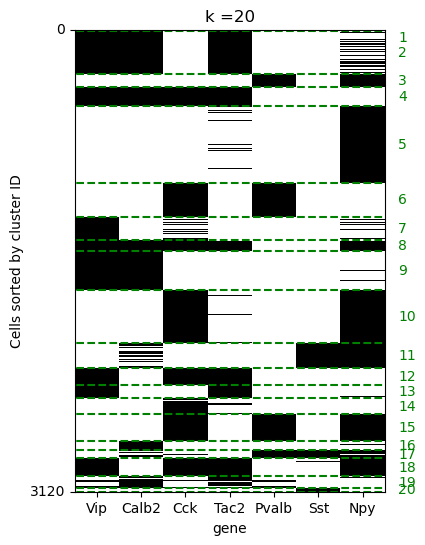

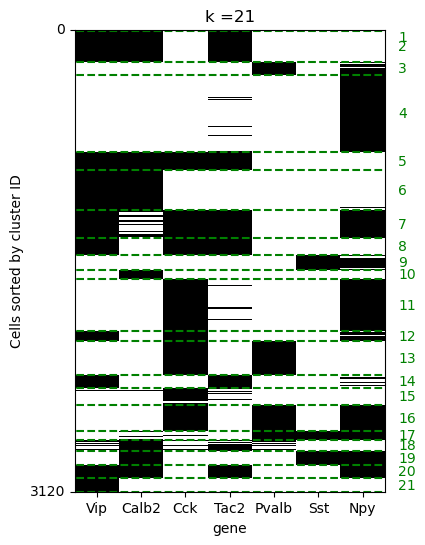

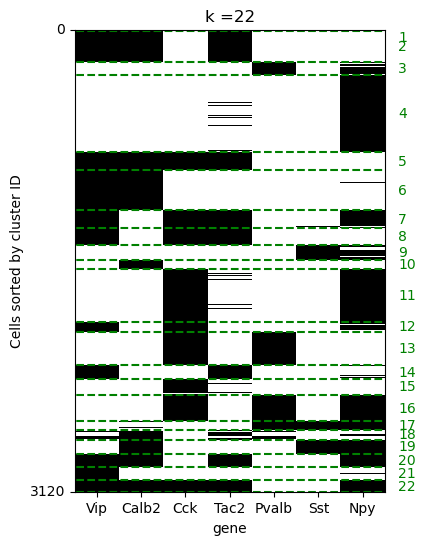

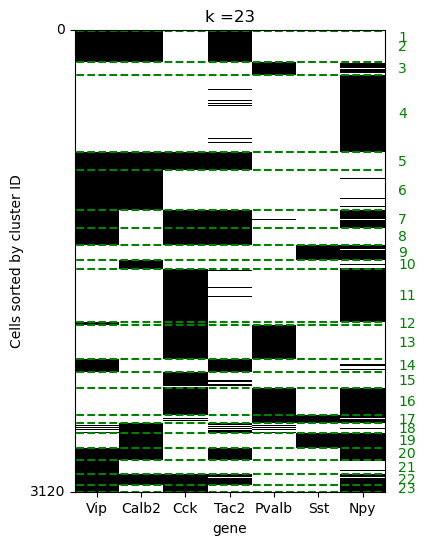

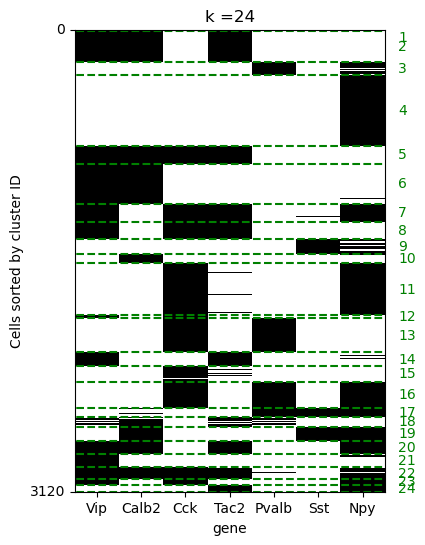

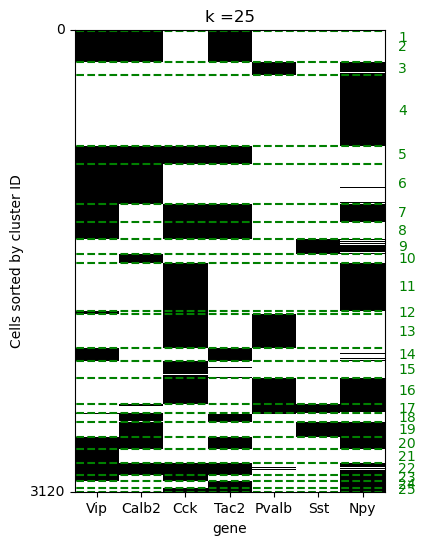

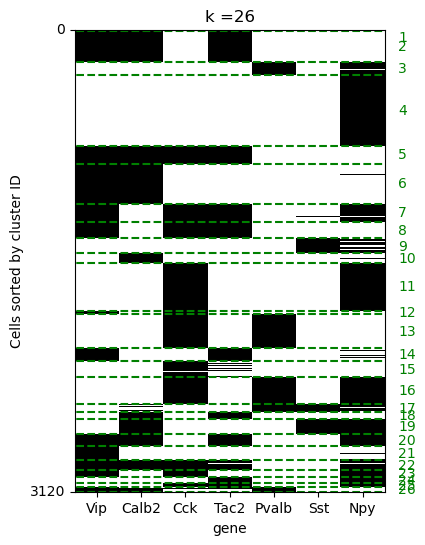

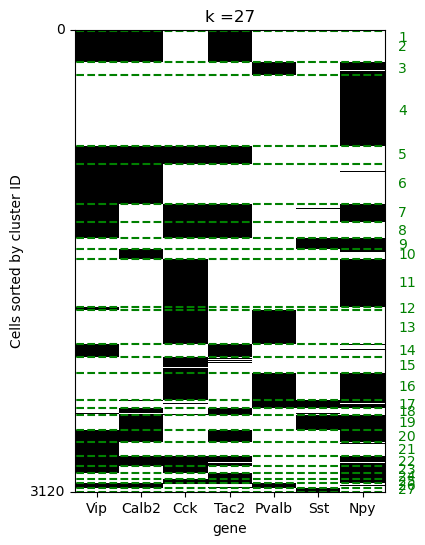

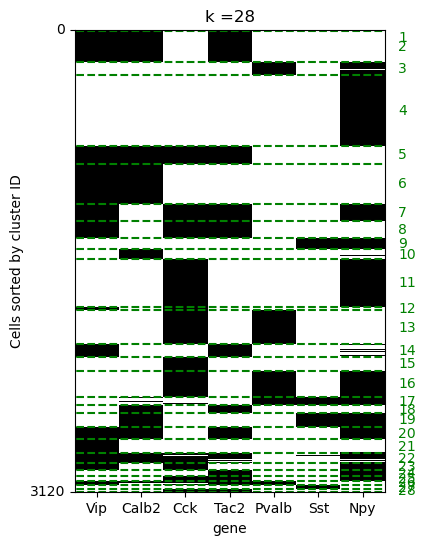

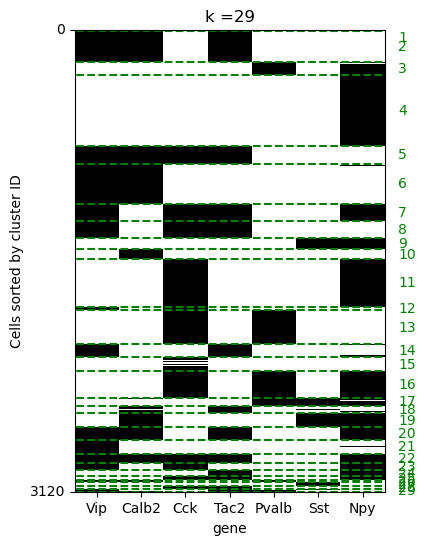

In [294]:
n_clusters_range = np.arange(10, 30)

for n_clusters in n_clusters_range:

    X = binary_tpm_data.copy()

    clusterer = KMeans(n_clusters=n_clusters, random_state=10, n_init='auto')
    cluster_labels = clusterer.fit_predict(X)

    X['cluster_id'] = cluster_labels
    plot_clustered_binary_cell_table(X, n_clusters)